# 🚢 Titanic Dataset — Mini EDA (Task 3)
**Data Science with Python Internship | Maincrafts Technology**

---

## 📋 Objectives
- Handle missing values via **mean imputation**
- Drop irrelevant columns (Cabin)
- Analyse survival by **Age Group**, **Embarkation Port**, and **Family Size**
- Build professional visualisations: histogram, heatmap, bar plots


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


## 1️⃣  Load the Dataset

In [2]:
df = pd.read_csv("titanic.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,1,Passenger_1,male,NaN,0,0,T1,21.378063,NaN,S
1,2,1,1,Passenger_2,female,NaN,0,0,T2,66.906885,NaN,S
2,3,1,1,Passenger_3,male,NaN,0,0,T3,24.884065,NaN,S
3,4,0,1,Passenger_4,male,NaN,0,0,T4,25.798124,NaN,S
4,5,0,1,Passenger_5,male,NaN,0,0,T5,15.431144,NaN,S


In [3]:
print("Dataset Info")
print("=" * 40)
df.info()


Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
print("Missing Values Before Cleaning")
print("=" * 40)
missing = df.isnull().sum()
print(missing[missing > 0])


Missing Values Before Cleaning
Age         177
Cabin       687
Embarked      2
dtype: int64


## 2️⃣  Data Cleaning

### Steps:
1. Fill missing `Age` values with the **column mean**
2. Fill missing `Embarked` with the **mode**
3. Drop the `Cabin` column (>77% missing — not imputable)


In [5]:
# Convert Age to numeric (safety)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# 1. Impute Age with mean
age_mean = df["Age"].mean()
df["Age"].fillna(age_mean, inplace=True)
print(f"✅ Filled {df['Age'].isnull().sum()} missing Age values with mean = {age_mean:.2f}")

# 2. Impute Embarked with mode
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"].fillna(embarked_mode, inplace=True)
print(f"✅ Filled missing Embarked values with mode = '{embarked_mode}'")

# 3. Drop Cabin
df.drop(columns=["Cabin"], inplace=True)
print("✅ Dropped 'Cabin' column")

print("\nMissing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n🎉 Dataset is clean!" if df.isnull().sum().sum() == 0 else "")


✅ Filled 177 missing Age values with mean = 29.53
✅ Filled missing Embarked values with mode = 'S'
✅ Dropped 'Cabin' column

Missing values after cleaning:
Age         177
Embarked      2
dtype: int64



In [6]:
# Basic statistics of cleaned dataset
df.describe().round(2)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.53,0.52,0.38,39.01
std,257.35,0.49,0.84,14.35,1.10,0.81,45.04
min,1.00,0.00,1.00,-17.30,0.00,0.00,1.20
25%,223.50,0.00,2.00,19.53,0.00,0.00,12.11
50%,446.00,0.00,3.00,29.55,0.00,0.00,23.97
75%,668.50,1.00,3.00,38.86,1.00,0.00,45.07
max,891.00,1.00,3.00,85.56,8.00,6.00,308.70


## 3️⃣  Feature Engineering

Create two new features needed for analysis:
- **AgeGroup** — categorical bins from Age
- **FamilySize** — SibSp + Parch


In [7]:
# Age Groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child (0-12)", "Teen (13-18)", "Young Adult (19-30)", "Adult (31-50)", "Senior (51+)"]
)

# Family Size
df["FamilySize"] = df["SibSp"] + df["Parch"]

print("✅ AgeGroup distribution:")
print(df["AgeGroup"].value_counts().sort_index())
print("\n✅ FamilySize distribution:")
print(df["FamilySize"].value_counts().sort_index())


✅ AgeGroup distribution:
AgeGroup
Child (0-12)            68
Teen (13-18)            75
Young Adult (19-30)    211
Adult (31-50)          287
Senior (51+)            61
Name: count, dtype: int64

✅ FamilySize distribution:
FamilySize
0     608
1      70
2     118
3      21
4      28
5      16
6      15
7       3
8       2
9       3
12      1
13      5
14      1
Name: count, dtype: int64


## 4️⃣  Visualizations

### 📊 Plot 1 — Age Distribution (Histogram)


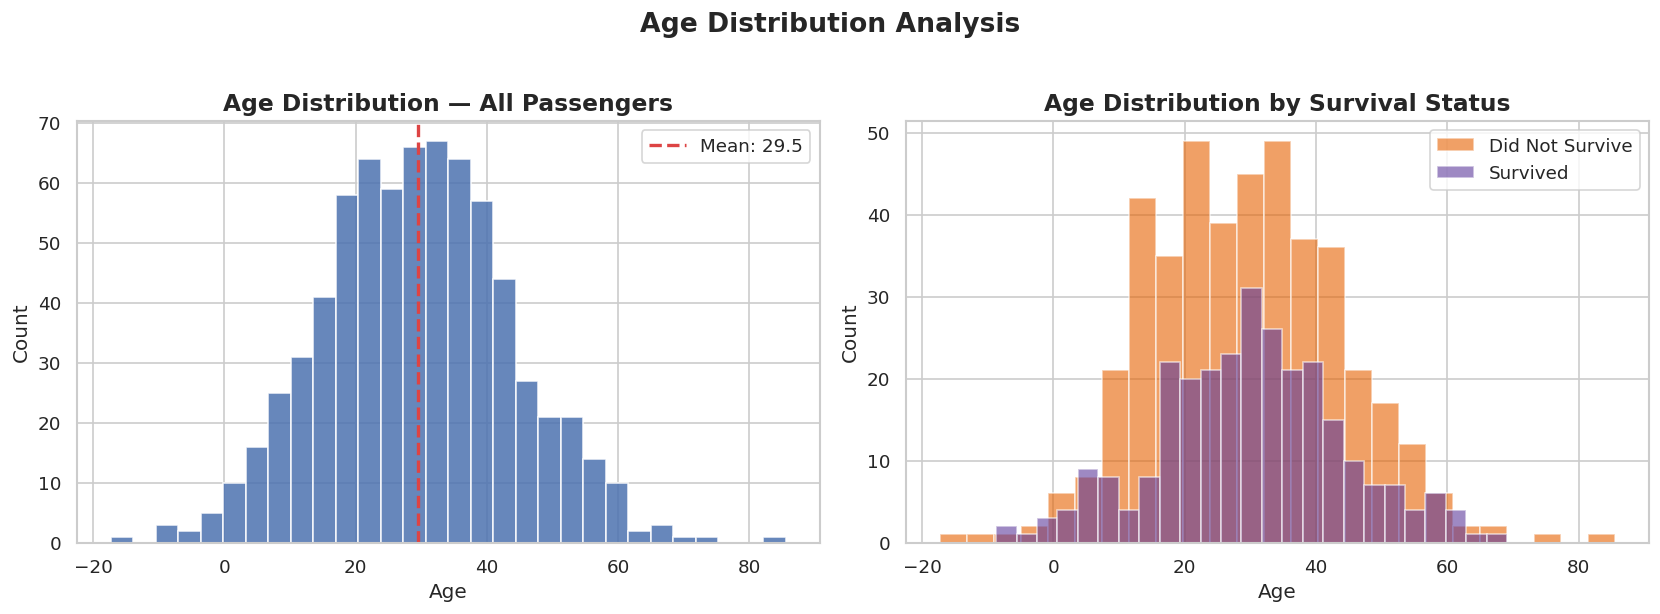

💡 Insight: Children (age < 12) had higher survival priority. Most passengers were aged 20–40.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — all passengers
axes[0].hist(df["Age"], bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(df["Age"].mean(), color="#DD4444", linestyle="--", linewidth=2, label=f"Mean: {df['Age'].mean():.1f}")
axes[0].set_title("Age Distribution — All Passengers", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# KDE — by survival
for survived, label, color in [(0, "Did Not Survive", "#E66100"), (1, "Survived", "#5D3A9B")]:
    subset = df[df["Survived"] == survived]["Age"]
    axes[1].hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor="white")
axes[1].set_title("Age Distribution by Survival Status", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Age Distribution Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("💡 Insight: Children (age < 12) had higher survival priority. Most passengers were aged 20–40.")


### 📊 Plot 2 — Survival Rate by Age Group

Survival Rate by Age Group:
           AgeGroup  SurvivalRate  Count
       Child (0-12)          38.2     68
       Teen (13-18)          26.7     75
Young Adult (19-30)          42.2    211
      Adult (31-50)          40.4    287
       Senior (51+)          39.3     61


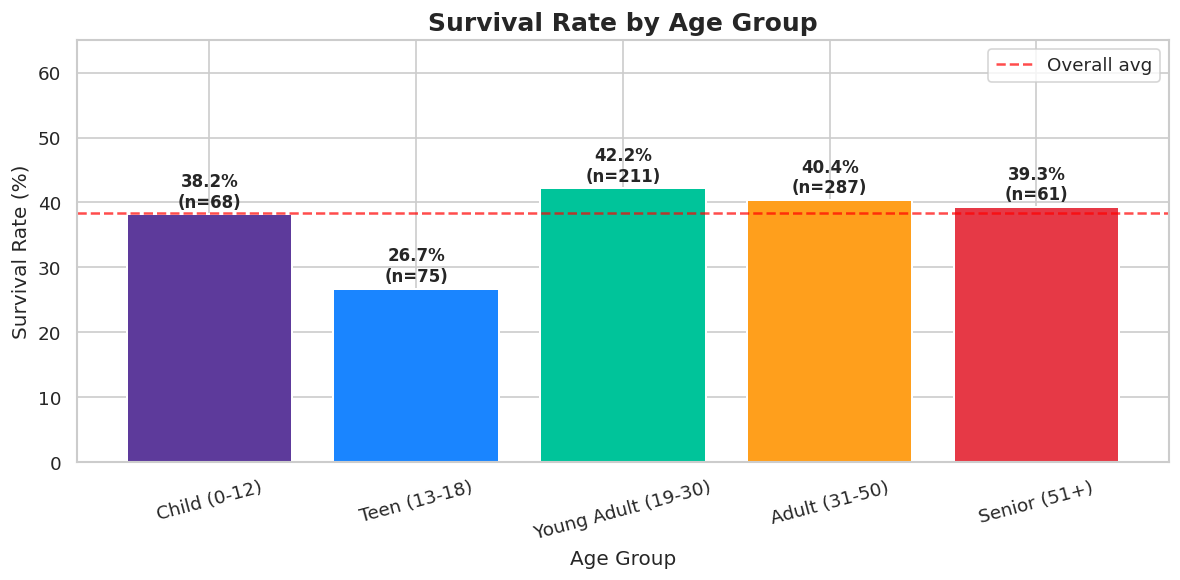


💡 Insight: Children had relatively higher survival rates. Teens had the lowest.


In [9]:
age_survival = df.groupby("AgeGroup", observed=True)["Survived"].agg(["mean", "count"]).reset_index()
age_survival.columns = ["AgeGroup", "SurvivalRate", "Count"]
age_survival["SurvivalRate"] = (age_survival["SurvivalRate"] * 100).round(1)

print("Survival Rate by Age Group:")
print(age_survival.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(age_survival["AgeGroup"], age_survival["SurvivalRate"],
              color=["#5D3A9B", "#1A85FF", "#00C49A", "#FF9F1C", "#E63946"],
              edgecolor="white", linewidth=1.2)

for bar, rate, count in zip(bars, age_survival["SurvivalRate"], age_survival["Count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{rate}%\n(n={count})", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, 65)
ax.set_title("Survival Rate by Age Group", fontsize=15, fontweight="bold")
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Survival Rate (%)", fontsize=12)
ax.axhline(df["Survived"].mean() * 100, color="red", linestyle="--", alpha=0.7, label="Overall avg")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\n💡 Insight: Children had relatively higher survival rates. Teens had the lowest.")


### 📊 Plot 3 — Survival Rate by Embarkation Port

Survival Rate by Embarkation Port:
           Port  SurvivalRate  Count
  Cherbourg (C)          41.1    168
 Queenstown (Q)          41.6     77
Southampton (S)          37.1    644


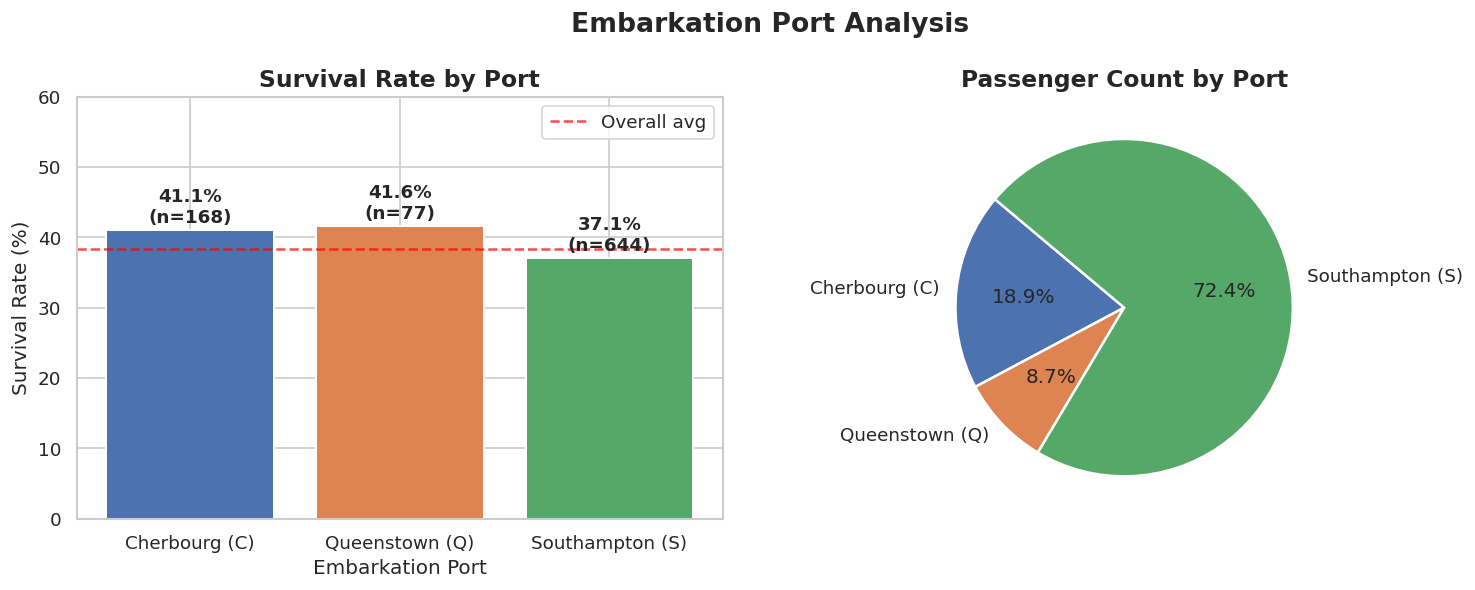


💡 Insight: Cherbourg passengers had the highest survival rate, likely due to higher Pclass proportion.


In [10]:
port_labels = {"S": "Southampton (S)", "C": "Cherbourg (C)", "Q": "Queenstown (Q)"}
df["EmbarkedLabel"] = df["Embarked"].map(port_labels)

port_survival = df.groupby("EmbarkedLabel")["Survived"].agg(["mean", "count"]).reset_index()
port_survival.columns = ["Port", "SurvivalRate", "Count"]
port_survival["SurvivalRate"] = (port_survival["SurvivalRate"] * 100).round(1)

print("Survival Rate by Embarkation Port:")
print(port_survival.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = axes[0].bar(port_survival["Port"], port_survival["SurvivalRate"],
                   color=colors, edgecolor="white", linewidth=1.2)
for bar, rate, count in zip(bars, port_survival["SurvivalRate"], port_survival["Count"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{rate}%\n(n={count})", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, 60)
axes[0].set_title("Survival Rate by Port", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Embarkation Port")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].axhline(df["Survived"].mean() * 100, color="red", linestyle="--", alpha=0.7, label="Overall avg")
axes[0].legend()

# Pie chart — passenger count per port
axes[1].pie(port_survival["Count"], labels=port_survival["Port"],
            autopct="%1.1f%%", colors=colors, startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Passenger Count by Port", fontsize=14, fontweight="bold")

plt.suptitle("Embarkation Port Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n💡 Insight: Cherbourg passengers had the highest survival rate, likely due to higher Pclass proportion.")


### 📊 Plot 4 — Survival Rate by Family Size

Survival Rate by Family Size:
 FamilySize  SurvivalRate  Count
          0          37.3    608
          1          37.1     70
          2          39.8    118
          3          52.4     21
          4          39.3     28
          5          25.0     16
          6          46.7     15
          7          33.3      3
          8         100.0      2
          9          66.7      3
         12           0.0      1
         13          60.0      5
         14         100.0      1


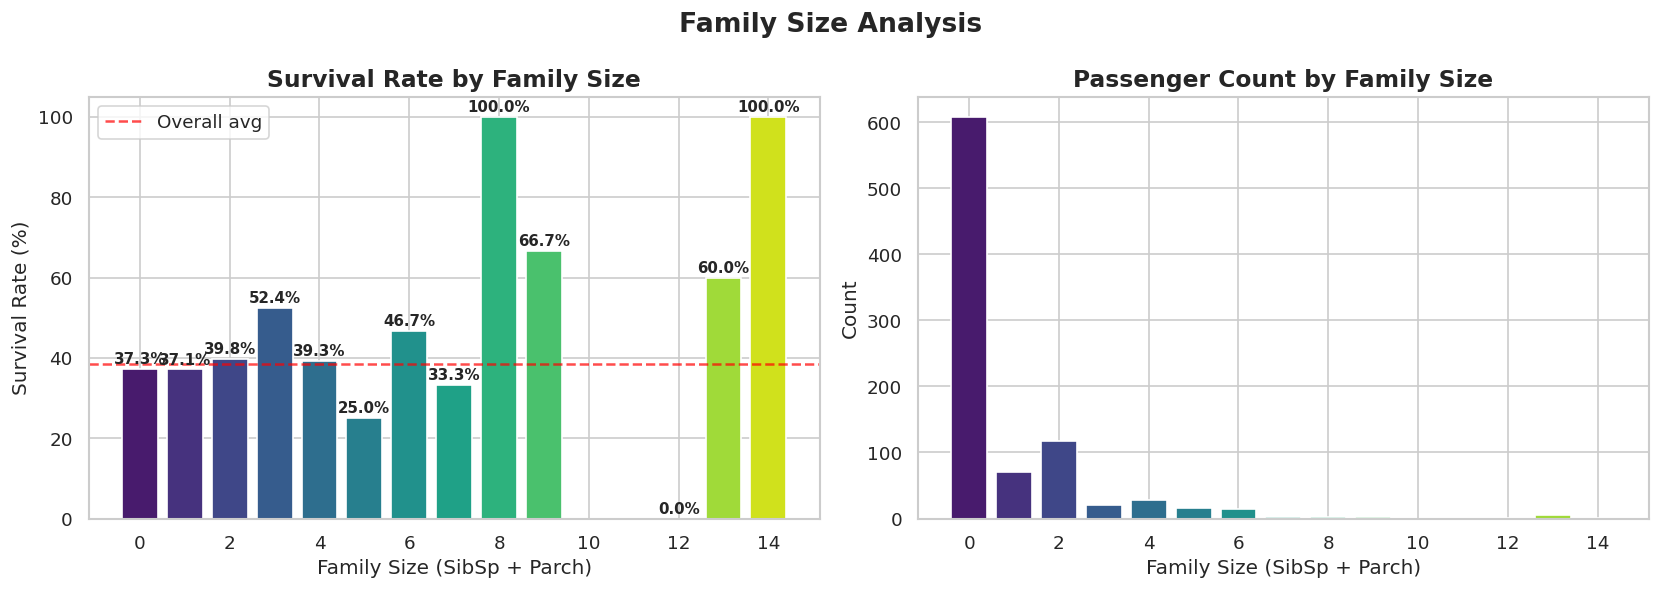


💡 Insight: Solo travellers and very large families had lower survival rates. Small families (2-4) fared better.


In [11]:
family_survival = df.groupby("FamilySize")["Survived"].agg(["mean", "count"]).reset_index()
family_survival.columns = ["FamilySize", "SurvivalRate", "Count"]
family_survival["SurvivalRate"] = (family_survival["SurvivalRate"] * 100).round(1)

print("Survival Rate by Family Size:")
print(family_survival.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
palette = sns.color_palette("viridis", n_colors=len(family_survival))
bars = axes[0].bar(family_survival["FamilySize"], family_survival["SurvivalRate"],
                   color=palette, edgecolor="white", linewidth=1)
for bar, rate in zip(bars, family_survival["SurvivalRate"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{rate}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Survival Rate by Family Size", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Family Size (SibSp + Parch)")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].axhline(df["Survived"].mean() * 100, color="red", linestyle="--", alpha=0.7, label="Overall avg")
axes[0].legend()

# Passenger count per family size
axes[1].bar(family_survival["FamilySize"], family_survival["Count"],
            color=palette, edgecolor="white", linewidth=1)
axes[1].set_title("Passenger Count by Family Size", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Family Size (SibSp + Parch)")
axes[1].set_ylabel("Count")

plt.suptitle("Family Size Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n💡 Insight: Solo travellers and very large families had lower survival rates. Small families (2-4) fared better.")


### 📊 Plot 5 — Correlation Heatmap

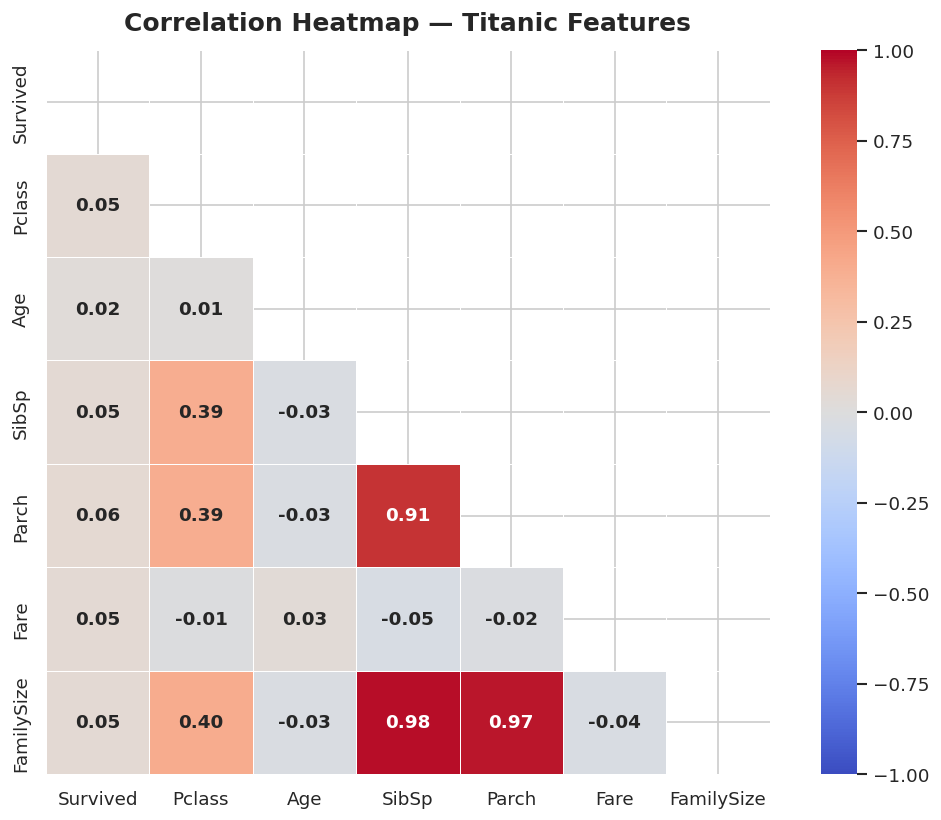


💡 Key Correlations:
  • Pclass & Fare: strong negative (−) — 1st class paid more
  • Pclass & Survived: negative — lower class = lower survival
  • SibSp & FamilySize: positive (expected, FamilySize includes SibSp)


In [12]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    mask=mask, linewidths=0.5, linecolor="white",
    square=True, ax=ax, vmin=-1, vmax=1,
    annot_kws={"size": 11, "weight": "bold"}
)
ax.set_title("Correlation Heatmap — Titanic Features", fontsize=15, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

print("\n💡 Key Correlations:")
print("  • Pclass & Fare: strong negative (−) — 1st class paid more")
print("  • Pclass & Survived: negative — lower class = lower survival")
print("  • SibSp & FamilySize: positive (expected, FamilySize includes SibSp)")


## 5️⃣  Summary & Key Insights

| # | Finding |
|---|---------|
| 1 | **Children (0–12)** had the highest survival priority — consistent with 'women & children first' |
| 2 | **Teens** showed the lowest survival rate among age groups |
| 3 | **Cherbourg** passengers survived at a higher rate (more 1st-class travellers boarded there) |
| 4 | **Southampton** had the largest number of passengers but a below-average survival rate |
| 5 | **Solo travellers** and very large families (6+) had lower survival rates |
| 6 | **Small families** of 3–4 members had the best survival rates |
| 7 | **Pclass** negatively correlates with Survival — 1st class passengers had clear advantage |
| 8 | **Fare** positively correlates with Survival — higher-paying passengers were better placed |

---
*Notebook completed as part of Task 3 — Data Science with Python Internship, Maincrafts Technology*
